# Route length vs additional HP

For trained agents from `agents/policy_iteration` and `agents/value_iteration` we measure route length (number of steps to finish or death) when starting from **(0, 0)** with different initial HP.

**Additional HP** = initial HP − minimum HP at (0,0) from the map (`min_hp[0,0]`). X-axis: additional HP, Y-axis: route length (or failure).

In [1]:
import sys
from pathlib import Path
import numpy as np
import yaml

root = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
sys.path.insert(0, str(root))

from src.environment import ParkourEnv
from src.utils.metrics import rollout_policy

In [2]:
def load_agent(agent_dir: Path):
    """Load policy, states, state_to_id, meta. Requires env for actions."""
    V = np.load(agent_dir / "value_function.npy")
    policy = np.load(agent_dir / "policy.npy")
    states_arr = np.load(agent_dir / "states.npy")
    states = [tuple(s) for s in states_arr]
    with open(agent_dir / "meta.yaml") as f:
        meta = yaml.safe_load(f)
    state_to_id = {s: i for i, s in enumerate(states)}
    return {"V": V, "policy": policy, "states": states, "state_to_id": state_to_id, "meta": meta}


def build_env_for_landscape(landscape_id: int, hp_start: int = 100):
    import os
    with open(root / "configs" / "env.yaml") as f:
        env_config = yaml.safe_load(f)
    env_config["landscape_id"] = landscape_id
    env_config["hp_start"] = hp_start
    old_cwd = os.getcwd()
    try:
        os.chdir(root)
        return ParkourEnv(env_config)
    finally:
        os.chdir(old_cwd)


def collect_agent_runs():
    """Collect paths to all saved agents (policy_iteration, value_iteration)."""
    runs = []
    for algo in ("policy_iteration", "value_iteration"):
        agents_dir = root / "agents" / algo
        if not agents_dir.exists():
            continue
        for path in sorted(agents_dir.iterdir()):
            if path.is_dir() and (path / "meta.yaml").exists() and (path / "policy.npy").exists():
                runs.append((algo, path))
    return runs

In [3]:
MAX_STEPS = 20000
EXTRA_HP_STEP = 5  # step for additional HP scan

runs = collect_agent_runs()
print(f"Runs found: {len(runs)}")
for algo, path in runs[:6]:
    print(f"  {algo}: {path.name}")

Найдено запусков: 20
  policy_iteration: 2026-03-16_20-37-53
  policy_iteration: 2026-03-16_20-38-29
  policy_iteration: 2026-03-16_20-39-05
  policy_iteration: 2026-03-16_20-39-44
  policy_iteration: 2026-03-16_20-40-20
  policy_iteration: 2026-03-16_20-40-55


In [4]:
results = []  # list of {algo, run_name, landscape_id, extra_hp, steps, victory}

for algo, agent_dir in runs:
    data = load_agent(agent_dir)
    meta = data["meta"]
    lid = meta["landscape_id"]
    env = build_env_for_landscape(lid, hp_start=100)
    actions = list(env.get_actions())
    landscape_dir = root / "landscape" / f"landscape_{lid}"
    min_hp_map = np.load(landscape_dir / "min_hp.npy")
    min_hp_start = int(min_hp_map[0, 0])
    if min_hp_start <= 0:
        min_hp_start = 1
    # Additional HP: 0, EXTRA_HP_STEP, 2*EXTRA_HP_STEP, ... up to 100 - min_hp_start
    max_extra = max(0, 100 - min_hp_start)
    extra_hp_values = list(range(0, max_extra + 1, EXTRA_HP_STEP))
    if extra_hp_values and extra_hp_values[-1] != max_extra:
        extra_hp_values.append(max_extra)

    for extra in extra_hp_values:
        start_hp = min_hp_start + extra
        if start_hp > 100:
            continue
        start_state = (0, 0, start_hp)
        r = rollout_policy(
            env, data["policy"], data["states"], actions, data["state_to_id"],
            max_steps=MAX_STEPS,
            start_state=start_state,
        )
        results.append({
            "algo": algo,
            "run_name": agent_dir.name,
            "landscape_id": lid,
            "extra_hp": extra,
            "start_hp": start_hp,
            "steps": r["steps"],
            "victory": r["victory"],
        })

print(f"Total measurements: {len(results)}")

Всего измерений: 278


/var/folders/y3/19gt23yd4zg9k93kytyfqj2w0000gn/T/ipykernel_18452/984982148.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(extra, steps, marker_linestyle, label=label, markersize=6, color=color, linestyle=ls)
/var/folders/y3/19gt23yd4zg9k93kytyfqj2w0000gn/T/ipykernel_18452/984982148.py:31: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s--" (-> linestyle='--'). The keyword argument will take precedence.
  ax.plot(extra, steps, marker_linestyle, label=label, markersize=6, color=color, linestyle=ls)


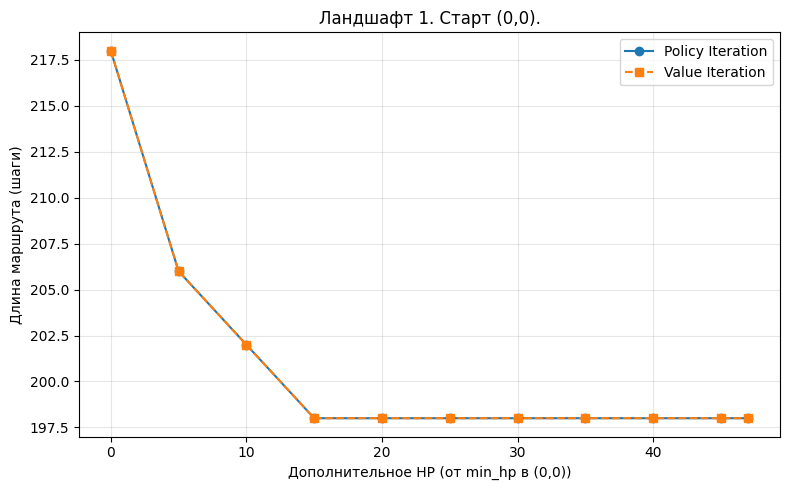

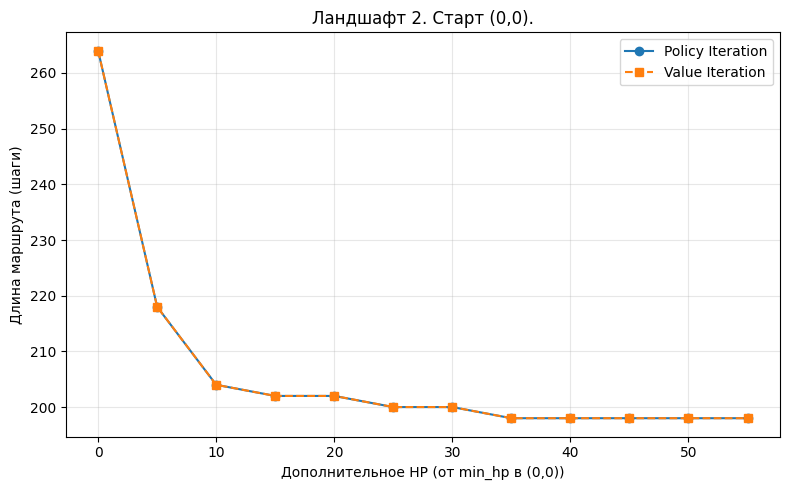

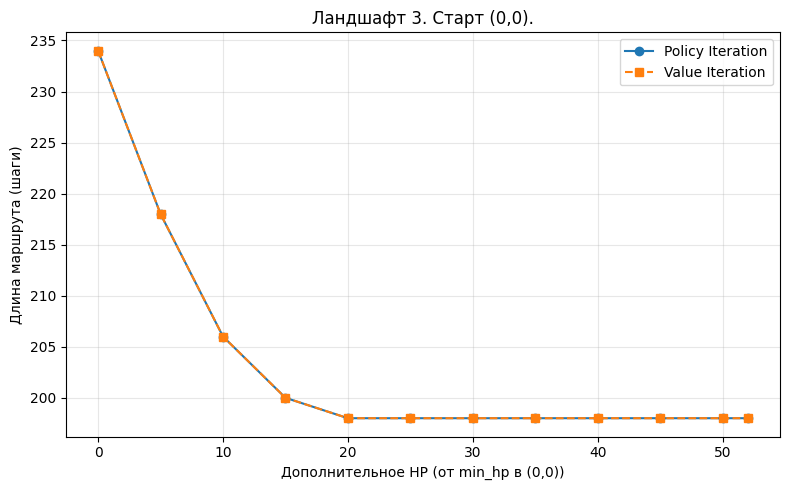

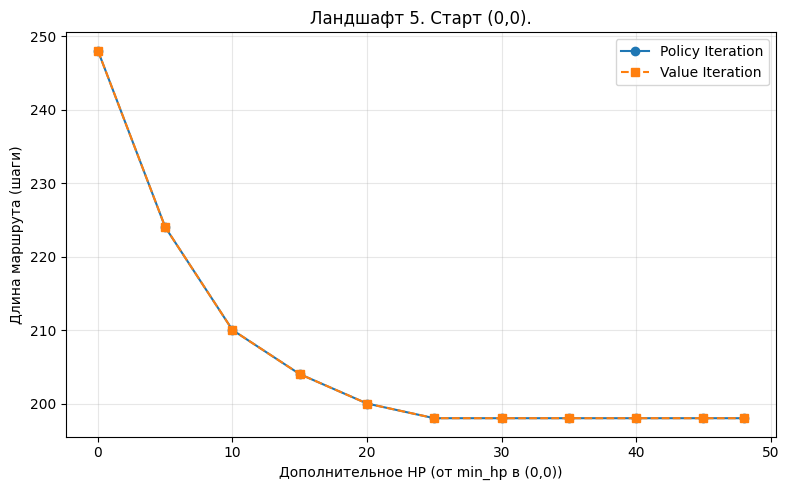

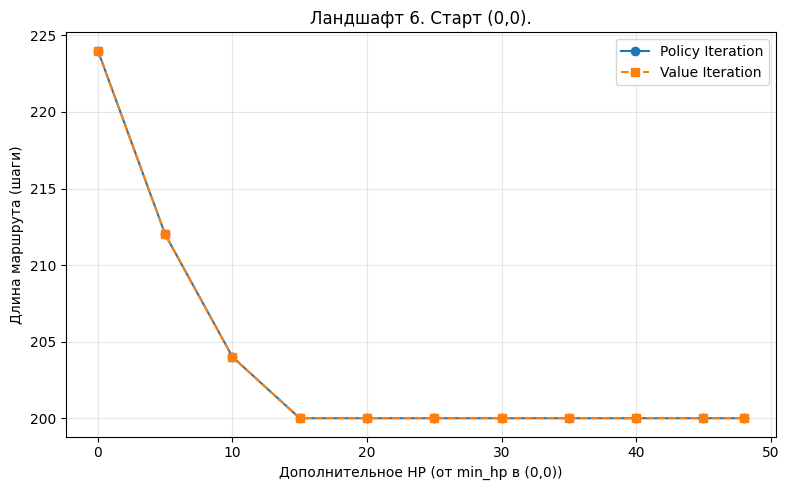

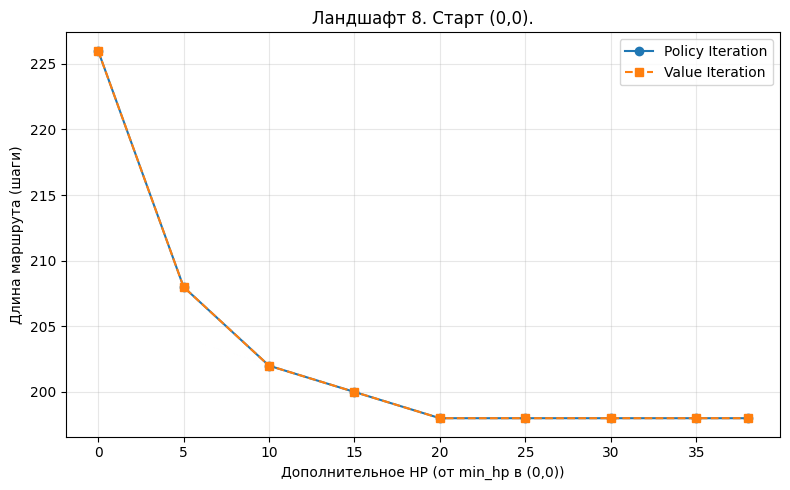

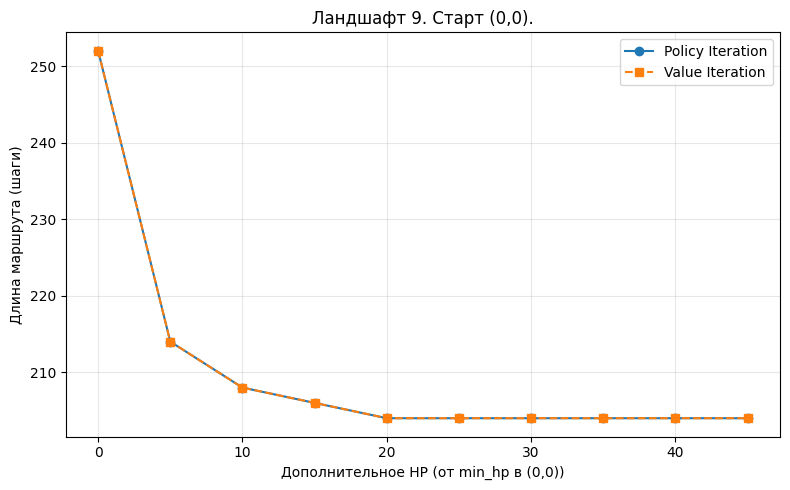

In [8]:
import matplotlib.pyplot as plt


landscapes = sorted({r["landscape_id"] for r in results if r["victory"]})

for lid in landscapes:
    sub = [r for r in results if r["landscape_id"] == lid]
    # One run per algorithm (latest by folder name)
    by_algo = {}
    for r in sub:
        key = r["algo"]
        if key not in by_algo or r["run_name"] > by_algo[key][0]["run_name"]:
            by_algo[key] = [x for x in sub if x["algo"] == key]
    # Plot using latest run per algorithm
    fig, ax = plt.subplots(figsize=(8, 5))
    styles = {"policy_iteration": ("C0", "o-", "solid"), "value_iteration": ("C1", "s--", "dashed")}
    for algo in ("policy_iteration", "value_iteration"):
        pts = [r for r in sub if r["algo"] == algo]
        if not pts:
            continue
        # One run per algorithm: group by extra_hp (may have duplicates across runs)
        run_names = {r["run_name"] for r in pts}
        latest_run = max(run_names)
        pts = [r for r in pts if r["run_name"] == latest_run]
        pts.sort(key=lambda x: x["extra_hp"])
        extra = [p["extra_hp"] for p in pts]
        steps = [p["steps"] for p in pts]
        victory = [p["victory"] for p in pts]
        label = algo.replace("_", " ").title()
        color, marker_linestyle, ls = styles[algo]
        ax.plot(extra, steps, marker_linestyle, label=label, markersize=6, color=color, linestyle=ls)
        fails = [i for i, v in enumerate(victory) if not v]
        if fails:
            ax.scatter([extra[i] for i in fails], [steps[i] for i in fails], color="red", s=80, zorder=5, marker="x")
    ax.set_xlabel("Additional HP (from min_hp at (0,0))")
    ax.set_ylabel("Route length (steps)")
    ax.set_title(f"Landscape {lid}. Start (0,0).")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

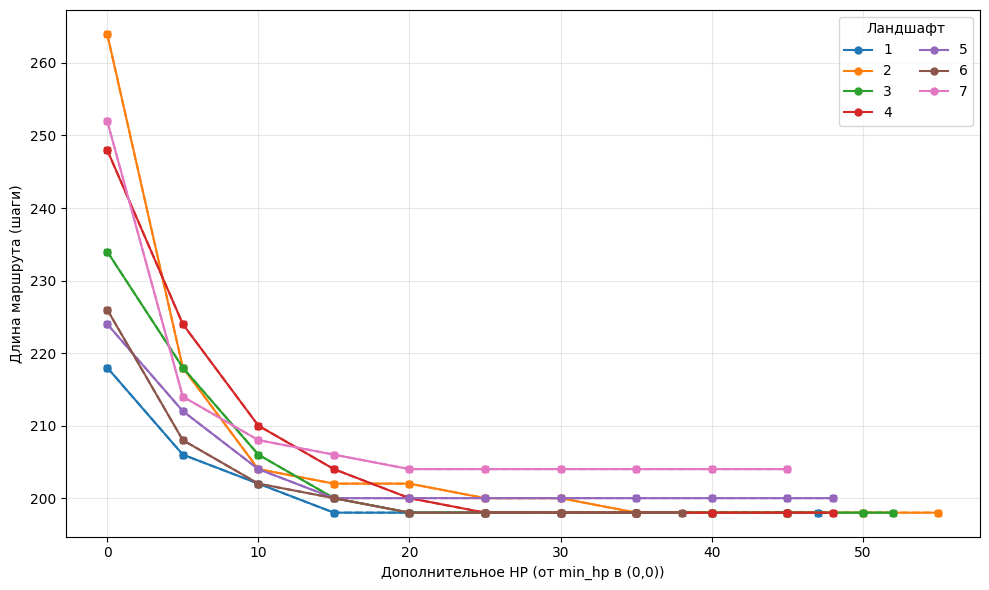

In [12]:

landscapes_all = sorted({r["landscape_id"] for r in results if r["victory"]})
if landscapes_all:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(landscapes_all))))
    for idx, lid in enumerate(landscapes_all):
        sub = [r for r in results if r["landscape_id"] == lid]
        c = colors[idx % len(colors)]
        lbl = str(idx + 1)
        for i, (algo, (mk, ls)) in enumerate([("policy_iteration", ("o", "-")), ("value_iteration", ("s", "--"))]):
            pts = [r for r in sub if r["algo"] == algo]
            if not pts:
                continue
            run_names = {r["run_name"] for r in pts}
            latest_run = max(run_names)
            pts = [r for r in pts if r["run_name"] == latest_run]
            pts.sort(key=lambda x: x["extra_hp"])
            extra = [p["extra_hp"] for p in pts]
            steps = [p["steps"] for p in pts]
            victory = [p["victory"] for p in pts]
            ax.plot(extra, steps, marker=mk, linestyle=ls, label=lbl if i == 0 else "_nolegend_", markersize=5, color=c)
            fails = [i for i, v in enumerate(victory) if not v]
            if fails:
                ax.scatter([extra[i] for i in fails], [steps[i] for i in fails], color=c, s=50, zorder=5, marker="x")
    ax.set_xlabel("Additional HP (from min_hp at (0,0))")
    ax.set_ylabel("Route length (steps)")
    ax.legend(title="Landscape", ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
# Summary table: for each (algo, landscape_id, extra_hp) — steps and victory
import pandas as pd

df = pd.DataFrame(results)
latest = df.groupby(["landscape_id", "algo"])["run_name"].max().reset_index()
df1 = df.merge(latest, on=["landscape_id", "algo", "run_name"])
pivot_steps = df1.pivot_table(index=["landscape_id", "extra_hp"], columns="algo", values="steps", aggfunc="first")
pivot_victory = df1.pivot_table(index=["landscape_id", "extra_hp"], columns="algo", values="victory", aggfunc="first")
print("Route length (steps):")
print(pivot_steps.head(20))
print("\nVictory (True/False):")
print(pivot_victory.head(20))

Длина маршрута (шаги):
algo                   policy_iteration  value_iteration
landscape_id extra_hp                                   
1            0                      218              218
             5                      206              206
             10                     202              202
             15                     198              198
             20                     198              198
             25                     198              198
             30                     198              198
             35                     198              198
             40                     198              198
             45                     198              198
             47                     198              198
2            0                      264              264
             5                      218              218
             10                     204              204
             15                     202              202
        